<a href="https://colab.research.google.com/github/tharun-kota/TCR_disease_prediction/blob/main/cdr3beta_epitope_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. DATA PRE-PROCESSING

In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import os

# --------------------------------------------------
# Settings
# --------------------------------------------------
MAX_LEN = 25
DATASET_DIR = "/content/dataset"

TRAIN_CSV = "/content/train_binary.csv"
TEST_CSV = "/content/test_binary.csv"

PEPTIDE_COL = "CDR3.beta.aa"
EPITOPE_COL = "Epitope.peptide"
LABEL_COL = "binary_label"

# Standard amino acids
standard_amino = 'ARNDCQEGHILKMFPSTWYV'

# Standard amino acids + X for unknown / missing / padded positions
all_amino = 'ARNDCQEGHILKMFPSTWYVX'

os.makedirs(DATASET_DIR, exist_ok=True)

# --------------------------------------------------
# Create amino-acid pair dictionary
# --------------------------------------------------
amino_pairs = []
for a1 in all_amino:
    for a2 in all_amino:
        amino_pairs.append(a1 + a2)

pair_to_id = {pair: idx + 1 for idx, pair in enumerate(amino_pairs)}
amino_to_id = {aa: idx + 1 for idx, aa in enumerate(all_amino)}

with open(f"{DATASET_DIR}/amino_to_id.json", "w") as f:
    json.dump(amino_to_id, f, indent=4)

with open(f"{DATASET_DIR}/pair_to_id.json", "w") as f:
    json.dump(pair_to_id, f, indent=4)

# Save binary label meaning
binary_label_map = {
    "Other": 0,
    "Neoantigen": 1
}

with open(f"{DATASET_DIR}/binary_label_map.json", "w") as f:
    json.dump(binary_label_map, f, indent=4)

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def normalize_amino_acid(aa):
    if aa in standard_amino:
        return aa
    return 'X'

def encode_pair_matrix(peptide, epitope, max_len=25):
    peptide = str(peptide)[:max_len].ljust(max_len, 'X')
    epitope = str(epitope)[:max_len].ljust(max_len, 'X')

    arr = np.zeros((max_len, max_len), dtype=np.int32)

    for i, p in enumerate(peptide):
        p = normalize_amino_acid(p)
        for j, e in enumerate(epitope):
            e = normalize_amino_acid(e)
            arr[i, j] = pair_to_id[p + e]

    return arr

def encode_dataframe(df, peptide_col, epitope_col, label_col):
    matrices = []
    labels = []

    for idx in tqdm(range(len(df)), desc="Encoding"):
        peptide = df.iloc[idx][peptide_col]
        epitope = df.iloc[idx][epitope_col]
        label = str(df.iloc[idx][label_col]).strip()

        # Binary classification
        binary_label = 1 if label == "Neoantigen" else 0

        matrices.append(encode_pair_matrix(peptide, epitope, max_len=MAX_LEN))
        labels.append(binary_label)

    X = np.asarray(matrices, dtype=np.int32)
    y = np.asarray(labels, dtype=np.int64)

    return X, y

# --------------------------------------------------
# Load data
# --------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# --------------------------------------------------
# Encode and save
# --------------------------------------------------
X_train, y_train = encode_dataframe(train_df, PEPTIDE_COL, EPITOPE_COL, LABEL_COL)
X_test, y_test = encode_dataframe(test_df, PEPTIDE_COL, EPITOPE_COL, LABEL_COL)

np.save(f"{DATASET_DIR}/X_train.npy", X_train)
np.save(f"{DATASET_DIR}/y_train.npy", y_train)
np.save(f"{DATASET_DIR}/X_test.npy", X_test)
np.save(f"{DATASET_DIR}/y_test.npy", y_test)

print("Encoding complete.")
print("Saved files:")
print(f" - {DATASET_DIR}/X_train.npy")
print(f" - {DATASET_DIR}/y_train.npy")
print(f" - {DATASET_DIR}/X_test.npy")
print(f" - {DATASET_DIR}/y_test.npy")
print(f" - {DATASET_DIR}/amino_to_id.json")
print(f" - {DATASET_DIR}/pair_to_id.json")
print(f" - {DATASET_DIR}/binary_label_map.json")

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Encoding: 100%|██████████| 72/72 [00:00<00:00, 959.36it/s]

Encoding complete.
Saved files:
 - /content/dataset/X_train.npy
 - /content/dataset/y_train.npy
 - /content/dataset/X_test.npy
 - /content/dataset/y_test.npy
 - /content/dataset/amino_to_id.json
 - /content/dataset/pair_to_id.json
 - /content/dataset/binary_label_map.json

Shapes:
X_train: (284, 25, 25)
y_train: (284,)
X_test : (72, 25, 25)
y_test : (72,)


# 2. DATA LOADER

In [8]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

DATASET_DIR = "/content/dataset"

class PairMatrixDataset(Dataset):
    def __init__(self, x_path, y_path):
        self.X = np.load(x_path)   # shape: (N, 25, 25)
        self.y = np.load(y_path)   # shape: (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        mult_id = torch.tensor(self.X[idx], dtype=torch.long)
        pep_mask = torch.ones(mult_id.shape[1], dtype=torch.long)  # length 25
        target = torch.tensor(self.y[idx], dtype=torch.long)

        return {
            "mult_id": mult_id,
            "pep_mask_len": pep_mask,
            "targets": target
        }

train_dataset = PairMatrixDataset(
    f"{DATASET_DIR}/X_train.npy",
    f"{DATASET_DIR}/y_train.npy"
)

test_dataset = PairMatrixDataset(
    f"{DATASET_DIR}/X_test.npy",
    f"{DATASET_DIR}/y_test.npy"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# quick check
batch = next(iter(train_loader))
print(batch["mult_id"].shape)      # (batch_size, 25, 25)
print(batch["pep_mask_len"].shape) # (batch_size, 25)
print(batch["targets"].shape)      # (batch_size,)

torch.Size([32, 25, 25])
torch.Size([32, 25])
torch.Size([32])


# 3. MODEL ARCHITECTURE

In [9]:
import torch
from torch import nn

class disease_mult_cnn(nn.Module):
    def __init__(self):
        super(disease_mult_cnn, self).__init__()

        self.mult_emb = nn.Embedding(441 + 1, 128)

        self.mult_id_step1 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(25, 1), padding='valid'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.mult_id_step2_1 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=128, kernel_size=1, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.mult_id_step2_2 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15)
        )

        self.mult_id_step2_3 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.id_step2_max = nn.Sequential(
            nn.MaxPool1d(2, 2),
            nn.Dropout(0.42)
        )

        self.mult_id_step3_1 = nn.Sequential(
            nn.Conv1d(in_channels=512, out_channels=128, kernel_size=1, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.mult_id_step3_2 = nn.Sequential(
            nn.Conv1d(in_channels=512, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.mult_id_step3_3 = nn.Sequential(
            nn.Conv1d(in_channels=512, out_channels=512, kernel_size=5, padding='same'),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )

        self.mult_id_step3_4 = nn.Sequential(
            nn.Conv1d(in_channels=512, out_channels=1024, kernel_size=7, padding='same'),
            nn.BatchNorm1d(1024),
            nn.ReLU()
        )

        self.id_step3_max = nn.Sequential(
            nn.MaxPool1d(3, 3),
            nn.Dropout(0.54)
        )

        self.id_step3_fusion = nn.Sequential(
            nn.Conv1d(in_channels=128 + 256 + 512 + 1024, out_channels=128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.id_rnn_step3_1 = nn.LSTM(128, 128, 1, batch_first=True, bidirectional=False)
        self.id_rnn_step3_2 = nn.LSTM(128, 128, 2, batch_first=True, bidirectional=False)

        self.id_mult_conv = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.fc = nn.Linear(256, 3)

    def forward(self, mult_id, pep_mask_len):
        # [B,25,25] -> [B,625]
        mult_id = mult_id.reshape(mult_id.shape[0], -1)

        # embedding lookup -> [B,625,128]
        mult_id = self.mult_emb(mult_id)

        # -> [B,128,25,25]
        mult_id = mult_id.reshape(mult_id.shape[0], 25, 25, -1).permute(0, 3, 1, 2)

        # -> [B,256,1,25] -> [B,256,25]
        mult_id = self.mult_id_step1(mult_id).squeeze(-2)

        # -> [B,512,25]
        mult_id = torch.cat([
            self.mult_id_step2_1(mult_id),
            self.mult_id_step2_2(mult_id),
            self.mult_id_step2_3(mult_id)
        ], dim=1)

        # pool along sequence length: [B,512,25] -> [B,512,12]
        mult_id = self.id_step2_max(mult_id)

        # -> [B,1920,12]
        mult_id = torch.cat([
            self.mult_id_step3_1(mult_id),
            self.mult_id_step3_2(mult_id),
            self.mult_id_step3_3(mult_id),
            self.mult_id_step3_4(mult_id)
        ], dim=1)

        # -> [B,1920,4]
        mult_id = self.id_step3_max(mult_id)

        # -> [B,128,4]
        mult_id = self.id_step3_fusion(mult_id)

        # LSTM expects [B,L,C] -> [B,4,128]
        mult_id = mult_id.permute(0, 2, 1)

        mult_id_1, _ = self.id_rnn_step3_1(mult_id)
        mult_id_2, _ = self.id_rnn_step3_2(mult_id)
        mult_id = torch.cat([mult_id_1, mult_id_2], dim=-1)  # [B,4,256]

        # -> [B,256,4] -> conv -> [B,256,4] -> [B,4,256]
        mult_id = self.id_mult_conv(mult_id.permute(0, 2, 1)).permute(0, 2, 1)

        # adjust mask to current sequence length
        masks_id = pep_mask_len[:, :mult_id.shape[1]].unsqueeze(-1).bool()

        # masked max pool over sequence dimension
        mult_id, _ = mult_id.masked_fill(~masks_id, -1e9).max(dim=1)

        # [B,256] -> [B,3]
        output = self.fc(mult_id)
        return output

# 4. TRAINING & EVALUATION

Epoch 1/20: 100%|██████████| 9/9 [00:18<00:00,  2.03s/it]



Epoch 1: train_loss=0.0224, train_acc=0.6866, train_f1_macro=0.4485, test_loss=0.0394, test_acc=0.8472, test_f1_macro=0.8358
Best model saved to /content/result/my_data/best_model.pt


Epoch 2/20: 100%|██████████| 9/9 [00:06<00:00,  1.46it/s]



Epoch 2: train_loss=0.0092, train_acc=0.8838, train_f1_macro=0.8774, test_loss=0.0260, test_acc=0.8194, test_f1_macro=0.8088


Epoch 3/20: 100%|██████████| 9/9 [00:06<00:00,  1.36it/s]


...


Epoch 18: train_loss=0.0001, train_acc=1.0000, train_f1_macro=1.0000, test_loss=0.0366, test_acc=0.7778, test_f1_macro=0.7445


Epoch 19/20: 100%|██████████| 9/9 [00:06<00:00,  1.37it/s]



Epoch 19: train_loss=0.0007, train_acc=0.9894, train_f1_macro=0.9890, test_loss=0.0335, test_acc=0.7778, test_f1_macro=0.7734


Epoch 20/20: 100%|██████████| 9/9 [00:05<00:00,  1.62it/s]



Epoch 20: train_loss=0.0017, train_acc=0.9789, train_f1_macro=0.9783, test_loss=0.0377, test_acc=0.8056, test_f1_macro=0.7764

Loading best model for final evaluation...

Final Test Results
Loss: 0.0394
Accuracy: 0.8472
F1 Macro: 0.8358
F1 Weighted: 0.8430
Precision Macro: 0.8647
Recall Macro: 0.8262
Confusion Matrix:
[[21  9]
 [ 2 40]]

Saved predictions to /content/result/my_data/test_predictions.csv


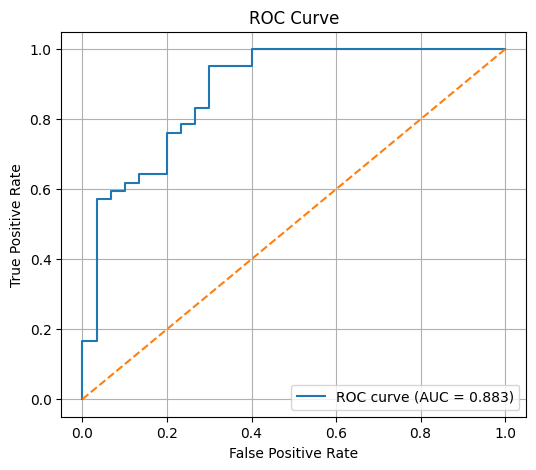

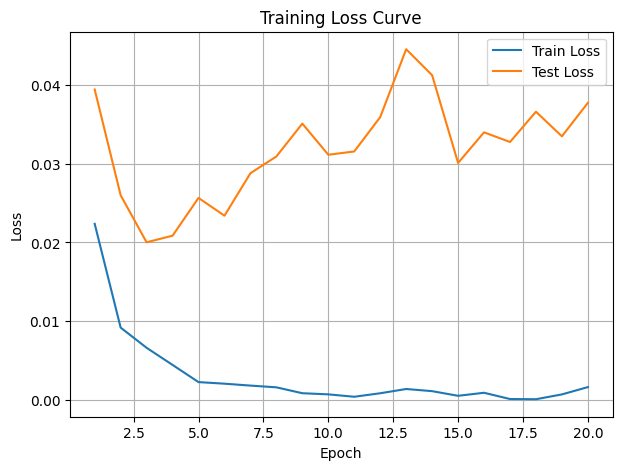

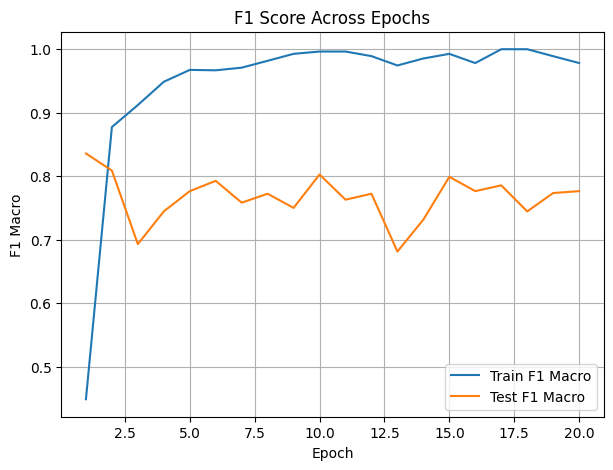

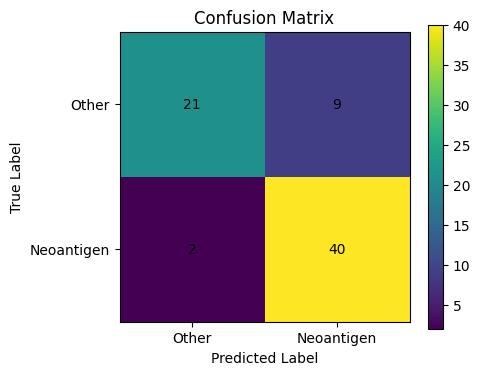

In [11]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)

# --------------------------------------------------
# Settings
# --------------------------------------------------
RESULT_DIR = "/content/result/my_data"
os.makedirs(RESULT_DIR, exist_ok=True)

EPOCHS = 20
LR = 0.001
WEIGHT_DECAY = 0.001
SEED = 9876
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
def same_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# --------------------------------------------------
# Metrics
# --------------------------------------------------
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

# --------------------------------------------------
# Evaluation
# --------------------------------------------------
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                mult_id=batch["mult_id"],
                pep_mask_len=batch["pep_mask_len"]
            )

            labels = batch["targets"]
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1]   # probability of positive class
            preds = outputs.argmax(dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics, np.array(all_labels), np.array(all_preds), np.array(all_probs)

# --------------------------------------------------
# Train
# --------------------------------------------------
same_seeds(SEED)

model = disease_mult_cnn().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

save_path = f"{RESULT_DIR}/best_model.pt"
best_test_f1 = -1

train_losses = []
test_losses = []
train_f1s = []
test_f1s = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    train_preds = []
    train_labels = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            mult_id=batch["mult_id"],
            pep_mask_len=batch["pep_mask_len"]
        )

        labels = batch["targets"]
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss = total_train_loss / len(train_loader.dataset)
    train_metrics = compute_metrics(train_labels, train_preds)

    test_loss, test_metrics, test_true, test_pred, test_probs = evaluate(
        model, test_loader, DEVICE, loss_fn
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_f1s.append(train_metrics["f1_macro"])
    test_f1s.append(test_metrics["f1_macro"])

    print(
        f"\nEpoch {epoch+1}: "
        f"train_loss={train_loss:.4f}, "
        f"train_acc={train_metrics['accuracy']:.4f}, "
        f"train_f1_macro={train_metrics['f1_macro']:.4f}, "
        f"test_loss={test_loss:.4f}, "
        f"test_acc={test_metrics['accuracy']:.4f}, "
        f"test_f1_macro={test_metrics['f1_macro']:.4f}"
    )

    if test_metrics["f1_macro"] > best_test_f1:
        best_test_f1 = test_metrics["f1_macro"]
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved to {save_path}")

# --------------------------------------------------
# Final evaluation
# --------------------------------------------------
print("\nLoading best model for final evaluation...")
model.load_state_dict(torch.load(save_path, map_location=DEVICE))

test_loss, test_metrics, test_true, test_pred, test_probs = evaluate(
    model, test_loader, DEVICE, loss_fn
)

print("\nFinal Test Results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"F1 Macro: {test_metrics['f1_macro']:.4f}")
print(f"F1 Weighted: {test_metrics['f1_weighted']:.4f}")
print(f"Precision Macro: {test_metrics['precision_macro']:.4f}")
print(f"Recall Macro: {test_metrics['recall_macro']:.4f}")
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

# --------------------------------------------------
# Save predictions
# --------------------------------------------------
out = pd.DataFrame({
    "true": test_true,
    "pred": test_pred,
    "prob_positive_class": test_probs
})
out.to_csv(f"{RESULT_DIR}/test_predictions.csv", index=False)
print(f"\nSaved predictions to {RESULT_DIR}/test_predictions.csv")

# --------------------------------------------------
# Plot 1: ROC Curve
# --------------------------------------------------
fpr, tpr, thresholds = roc_curve(test_true, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# Plot 2: Loss curve (gradient descent progress)
# --------------------------------------------------
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# Plot 3: F1 curve
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_f1s, label="Train F1 Macro")
plt.plot(epochs, test_f1s, label="Test F1 Macro")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("F1 Score Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# Optional: Confusion matrix heatmap
# --------------------------------------------------
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Other", "Neoantigen"])
plt.yticks([0, 1], ["Other", "Neoantigen"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()